In [8]:
import polars as pl

# 1. Загрузка
events_scan = pl.scan_csv("events.csv")
orders_scan = pl.scan_csv("data.csv")

# 2. Подготовка ORDERS: агрегируем доход и расходы на уровне ЮЗЕРА
# Приводим user_id к String, чтобы точно совпало с events, если там строки
orders_user_stats = (
    orders_scan
    .with_columns(pl.col("user_id").cast(pl.String)) 
    .group_by("user_id")
    .agg([
        pl.col("sale_price").sum().alias("total_revenue"),
        pl.col("cost").sum().alias("total_margin_cost"),
        pl.len().alias("total_items_bought"),
        pl.col("order_id").n_unique().alias("total_orders")
    ])
)

# 3. Подготовка EVENTS: восстанавливаем ID внутри сессий
events_prepared = (
    events_scan
    .with_columns([
        # Пытаемся найти ID пользователя в сессии, если он где-то "засветился"
        pl.col("user_id").min().over("session_id").alias("session_user_id")
    ])
    .with_columns([
        # Заполняем пустоты: если user_id null, берем найденный в сессии
        pl.coalesce([pl.col("user_id"), pl.col("session_user_id")]).alias("final_user_id")
    ])
    # Убираем совсем анонимные сессии, где ID так и не появился (для фин. анализа они бесполезны)
    .filter(pl.col("final_user_id").is_not_null())
)

# 4. МЁРДЖ (LEFT JOIN)
# Приклеиваем финансовую историю юзера к каждому его шагу в событиях
full_analysis_df = (
    events_prepared
    .join(
        orders_user_stats,
        left_on="final_user_id",
        right_on="user_id",
        how="left"
    )
    .with_columns([
        # Заменяем NaN на 0 для тех, кто залогинился, но ничего не купил
        pl.col("total_revenue").fill_null(0.0),
        pl.col("total_margin_cost").fill_null(0.0),
        pl.col("total_orders").fill_null(0)
    ])
    .with_columns([
        # Считаем чистую прибыль с юзера (LTV)
        (pl.col("total_revenue") - pl.col("total_margin_cost")).alias("user_lifetime_profit")
    ])
)

# 5. Проверка финальной структуры
final_sample = full_analysis_df.head(10).collect()
print("--- СТРУКТУРА ОБЪЕДИНЕННОГО ДАТАСЕТА ---")
print(final_sample.select([
    "final_user_id", "session_id", "event_type", "total_revenue", "user_lifetime_profit"
]))

# 6. Проверка пересечения после фикса типов
check_join = full_analysis_df.filter(pl.col("total_revenue") > 0).select("final_user_id").head(1).collect()
if check_join.is_empty():
    print("\nПРЕДУПРЕЖДЕНИЕ: Пересечение все еще 0. Проверь форматы ID вручную.")
else:
    print("\nУСПЕХ: Данные склеились.")

--- СТРУКТУРА ОБЪЕДИНЕННОГО ДАТАСЕТА ---
shape: (10, 5)
┌───────────────┬──────────────────────────────┬────────────┬───────────────┬──────────────────────┐
│ final_user_id ┆ session_id                   ┆ event_type ┆ total_revenue ┆ user_lifetime_profit │
│ ---           ┆ ---                          ┆ ---        ┆ ---           ┆ ---                  │
│ str           ┆ str                          ┆ str        ┆ f64           ┆ f64                  │
╞═══════════════╪══════════════════════════════╪════════════╪═══════════════╪══════════════════════╡
│ 11694         ┆ 74e6f624-e950-4f30-9cc9-0633 ┆ cart       ┆ 370.680004    ┆ 179.566682           │
│               ┆ 53…                          ┆            ┆               ┆                      │
│ 64883         ┆ e8c0f185-341d-4d14-a29b-4500 ┆ cart       ┆ 1014.269995   ┆ 486.488187           │
│               ┆ 17…                          ┆            ┆               ┆                      │
│ 2513          ┆ 09d886cb-b1cb-43a

In [9]:

# 2. ПОДГОТОВКА ИВЕНТОВ (Восстановление ID и фильтрация уникальных)
events_filled = (
    events_scan
    .unique(subset=["session_id", "created_at", "event_type"])
    .with_columns(
        filled_user_id = pl.col("user_id").min().over("session_id")
    )
    .with_columns(
        final_user_id = pl.coalesce([pl.col("user_id"), pl.col("filled_user_id")])
    )
)

# 3. АГРЕГАЦИЯ ФИНАНСОВ (Из таблицы заказов)
orders_stats = (
    orders_scan
    .with_columns(pl.col("user_id").cast(pl.String)) # Приведение типов для Join
    .group_by("user_id")
    .agg([
        pl.col("sale_price").sum().alias("total_revenue"),
        pl.col("cost").sum().alias("total_cost")
    ])
)

# 4. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ
user_segments = (
    events_filled
    .filter(pl.col("final_user_id").is_not_null())
    .group_by("final_user_id")
    .agg(pl.col("session_id").n_unique().alias("sessions_count"))
    .join(orders_stats, left_on="final_user_id", right_on="user_id", how="left")
    .with_columns([
        pl.col("total_revenue").fill_null(0.0),
        pl.when(pl.col("sessions_count") == 1).then(pl.lit("One-timer"))
          .when(pl.col("sessions_count") <= 3).then(pl.lit("Regular"))
          .otherwise(pl.lit("Heavy User"))
          .alias("user_type")
    ])
)

# 5. ПОДГОТОВКА СОБЫТИЙ С МЕТКАМИ СЕГМЕНТОВ
events_with_seg = (
    events_filled
    .join(user_segments.select(["final_user_id", "user_type"]), on="final_user_id", how="inner")
)

# 6. ФУНКЦИЯ РАСЧЕТА МЕТРИК (Исправленная логика CR)
def get_segmented_metrics(df_events, segment_name):
    # А) Данные по всему сегменту (база для ARPU и CR)
    seg_summary = (
        user_segments
        .filter(pl.col("user_type") == segment_name)
        .select([
            pl.len().alias("total_users"),
            pl.col("total_revenue").sum().alias("rev"),
            pl.col("sessions_count").sum().alias("sess")
        ])
        .collect()
    )
    
    n_users = seg_summary["total_users"][0]
    total_rev = seg_summary["rev"][0]
    total_sess = seg_summary["sess"][0]
    
    # Б) Считаем только тех, кто совершил покупку в этом сегменте
    # Используем уникальных пользователей, чтобы CR не раздувался от повторных покупок
    purchase_users = (
        df_events
        .filter((pl.col("user_type") == segment_name) & (pl.col("event_type") == "purchase"))
        .select(pl.col("final_user_id").n_unique())
        .collect()
        .item()
    )

    return pl.DataFrame({
        "segment": [segment_name],
        "conversion_to_purchase": [round(purchase_users / n_users, 4) if n_users > 0 else 0],
        "ARPU": [round(total_rev / n_users, 2) if n_users > 0 else 0],
        "ARPS": [round(total_rev / total_sess, 2) if total_sess > 0 else 0],
        "users_count": [n_users]
    })

# 7. СБОРКА И ВЫВОД
final_report = pl.concat([
    get_segmented_metrics(events_with_seg, s) 
    for s in ["One-timer", "Regular", "Heavy User"]
])

print("--- ИТОГОВЫЙ ОТЧЕТ: КОРРЕКТНАЯ КОНВЕРСИЯ И ЭКОНОМИКА ---")
print(final_report.sort("ARPU", descending=True))

--- ИТОГОВЫЙ ОТЧЕТ: КОРРЕКТНАЯ КОНВЕРСИЯ И ЭКОНОМИКА ---
shape: (3, 5)
┌────────────┬────────────────────────┬────────┬────────┬─────────────┐
│ segment    ┆ conversion_to_purchase ┆ ARPU   ┆ ARPS   ┆ users_count │
│ ---        ┆ ---                    ┆ ---    ┆ ---    ┆ ---         │
│ str        ┆ f64                    ┆ f64    ┆ f64    ┆ i64         │
╞════════════╪════════════════════════╪════════╪════════╪═════════════╡
│ Heavy User ┆ 1.0                    ┆ 899.74 ┆ 178.79 ┆ 15530       │
│ Regular    ┆ 1.0                    ┆ 417.35 ┆ 178.9  ┆ 29471       │
│ One-timer  ┆ 1.0                    ┆ 176.94 ┆ 176.94 ┆ 35020       │
└────────────┴────────────────────────┴────────┴────────┴─────────────┘


In [11]:
import polars as pl

# Считаем итоговый отчет
check_report_df = (
    session_analysis
    .join(finance_density, on="user_type")
    # Сортируем ДО селекта и переименования, пока колонка еще называется avg_ltv
    .sort("avg_ltv") 
    .select([
        "user_type",
        pl.col("avg_clicks_in_session").round(2).alias("Сложность сессии (клики)"),
        pl.col("session_conversion_rate").round(4).alias("CR сессии (реальный)"),
        pl.col("avg_sessions_per_user").round(2).alias("Частота визитов"),
        pl.col("avg_arps_check").round(2).alias("Выхлоп с сессии (ARPS)"),
        pl.col("avg_ltv").round(2).alias("Ценность юзера (LTV)")
    ])
    .collect()
)

print("--- ПРОВЕРКА ГИПОТЕЗЫ: АНАЛИЗ ПОВЕДЕНЧЕСКОЙ ЭНТРОПИИ ---")
print(check_report_df)

--- ПРОВЕРКА ГИПОТЕЗЫ: АНАЛИЗ ПОВЕДЕНЧЕСКОЙ ЭНТРОПИИ ---
shape: (3, 6)
┌────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ user_type  ┆ Сложность       ┆ CR сессии      ┆ Частота        ┆ Выхлоп с       ┆ Ценность юзера │
│ ---        ┆ сессии (клики)  ┆ (реальный)     ┆ визитов        ┆ сессии (ARPS)  ┆ (LTV)          │
│ str        ┆ ---             ┆ ---            ┆ ---            ┆ ---            ┆ ---            │
│            ┆ f64             ┆ f64            ┆ f64            ┆ f64            ┆ f64            │
╞════════════╪═════════════════╪════════════════╪════════════════╪════════════════╪════════════════╡
│ One-timer  ┆ 5.0             ┆ 1.0            ┆ 1.0            ┆ 176.94         ┆ 176.94         │
│ Regular    ┆ 6.46            ┆ 1.0            ┆ 2.33           ┆ 178.4          ┆ 417.35         │
│ Heavy User ┆ 8.82            ┆ 1.0            ┆ 5.03           ┆ 178.83         ┆ 899.74         │
└────────────┴──────

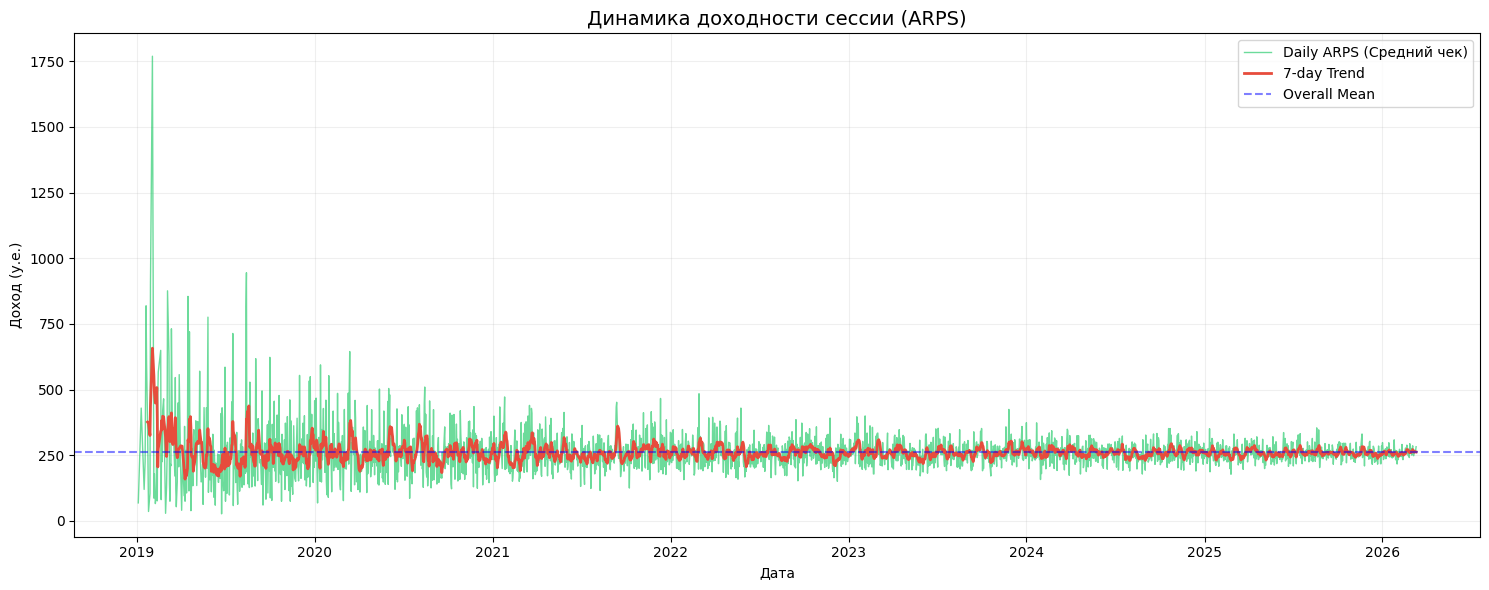

Средний ARPS по системе: 260.80


In [19]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Считаем данные, обрезая строку до даты (метод "с плеча")
orders_daily = (
    orders_scan
    .with_columns(
        # Берем первые 10 символов '2022-12-27', игнорируя всё остальное
        date = pl.col("created_at").str.slice(0, 10).str.to_datetime("%Y-%m-%d").dt.date()
    )
    .group_by("date")
    .agg([
        pl.col("sale_price").sum().alias("daily_revenue"),
        pl.col("order_id").n_unique().alias("daily_orders")
    ])
    .with_columns(
        arps_t = pl.col("daily_revenue") / pl.col("daily_orders")
    )
    .sort("date")
    .collect()
)

# 2. Визуализация
plt.figure(figsize=(15, 6))

# Подготовка данных для matplotlib (через списки для надежности)
x = orders_daily["date"].to_list()
y = orders_daily["arps_t"].to_list()

plt.plot(x, y, label="Daily ARPS (Средний чек)", color="#2ecc71", linewidth=1, alpha=0.7)

# Добавляем скользящее среднее для тренда
y_smooth = orders_daily["arps_t"].rolling_mean(window_size=7).to_list()
plt.plot(x, y_smooth, label="7-day Trend", color="#e74c3c", linewidth=2)

# Оформление
plt.title("Динамика доходности сессии (ARPS)", fontsize=14)
plt.xlabel("Дата")
plt.ylabel("Доход (у.е.)")
plt.axhline(orders_daily["arps_t"].mean(), color='blue', linestyle='--', alpha=0.5, label="Overall Mean")
plt.grid(True, alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Средний ARPS по системе: {orders_daily['arps_t'].mean():.2f}")

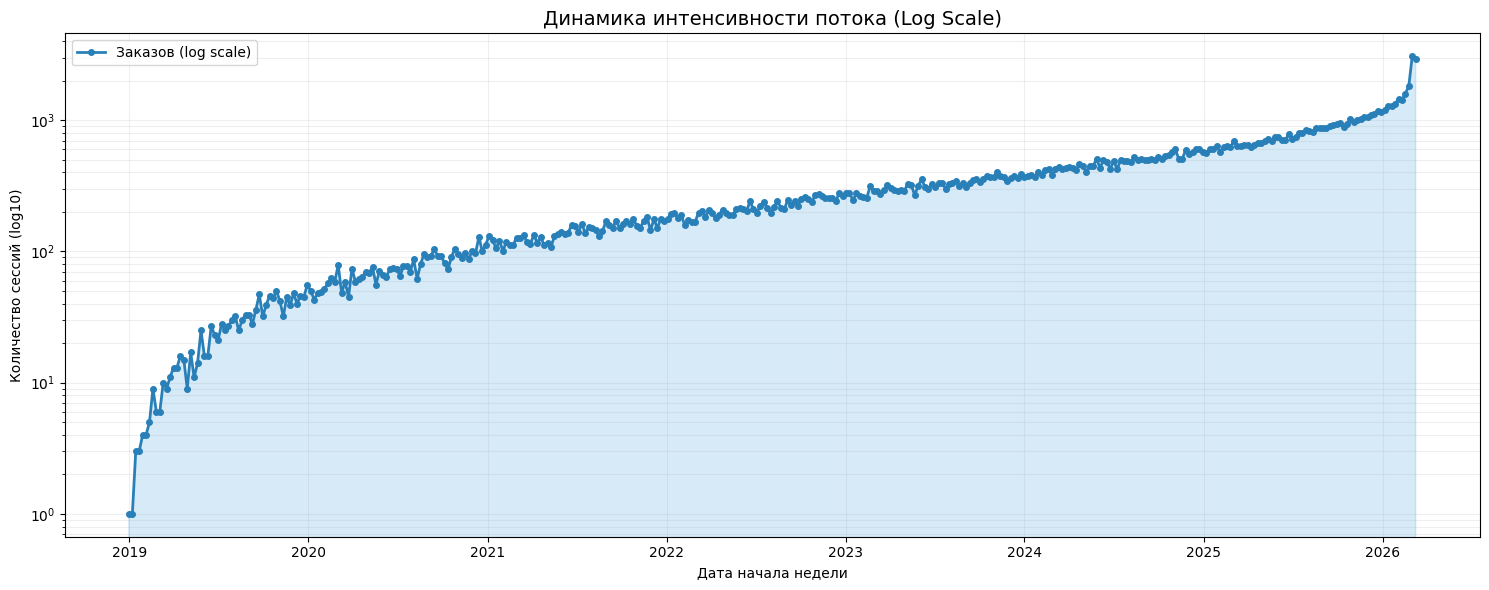

Средняя нагрузка: 333 сессий/нед


In [23]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Агрегируем сессии по неделям (код без изменений)
sessions_weekly = (
    orders_scan
    .with_columns(
        date = pl.col("created_at").str.slice(0, 10).str.to_datetime("%Y-%m-%d").dt.date()
    )
    .sort("date") 
    .group_by_dynamic("date", every="1w")
    .agg([
        pl.col("order_id").n_unique().alias("weekly_sessions")
    ])
    .collect()
)

# 2. Строим график в LOG масштабе
plt.figure(figsize=(15, 6))

x = sessions_weekly["date"].to_list()
y = sessions_weekly["weekly_sessions"].to_list()

# Используем step или обычный plot, на лог-шкале бары иногда выглядят громоздко
plt.plot(x, y, color="#2980b9", marker='o', markersize=4, linewidth=2, label="Заказов (log scale)")
plt.fill_between(x, y, color="#3498db", alpha=0.2)

# ВКЛЮЧАЕМ ЛОГАРИФМИЧЕСКУЮ ШКАЛУ
plt.yscale('log')

plt.title("Динамика интенсивности потока (Log Scale)", fontsize=14)
plt.xlabel("Дата начала недели")
plt.ylabel("Количество сессий (log10)")
plt.grid(True, which="both", ls="-", alpha=0.2) # 'both' покажет сетку и для доп. делений логарифма
plt.legend()
plt.tight_layout()
plt.show()

print(f"Средняя нагрузка: {sessions_weekly['weekly_sessions'].mean():.0f} сессий/нед")